# Data provisioning

## Split labels into separate columns

In [47]:
import pandas as pd

df_categories = pd.read_csv("../data/raw/original/disaster_categories.csv")
cats = df_categories[["id", "categories"]].copy()
cats_expanded = cats["categories"].str.split(";", expand=True)
row = cats_expanded.iloc[0]
category_colnames = row.apply(lambda x: x.split("-")[0])
cats_expanded.columns = category_colnames
categories = pd.concat([cats["id"], cats_expanded], axis=1)
categories.head()

,id,related,request,offer,aid_related,medical_help,medical_products,search_and_rescue,security,military,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,2,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
1,7,related-1,request-0,offer-0,aid_related-1,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-1,floods-0,storm-1,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
2,8,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
3,9,related-1,request-1,offer-0,aid_related-1,medical_help-0,medical_products-1,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
4,12,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0


## Convert columns to numeric values

In [48]:
for column in categories.columns:
    if column != "id":
        categories[column] = categories[column].str.split("-").str[-1].astype(int)

print(categories.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26248 entries, 0 to 26247
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      26248 non-null  int64
 1   related                 26248 non-null  int64
 2   request                 26248 non-null  int64
 3   offer                   26248 non-null  int64
 4   aid_related             26248 non-null  int64
 5   medical_help            26248 non-null  int64
 6   medical_products        26248 non-null  int64
 7   search_and_rescue       26248 non-null  int64
 8   security                26248 non-null  int64
 9   military                26248 non-null  int64
 10  child_alone             26248 non-null  int64
 11  water                   26248 non-null  int64
 12  food                    26248 non-null  int64
 13  shelter                 26248 non-null  int64
 14  clothing                26248 non-null  int64
 15  money              

## Check all unique values per column

In [49]:
binary_check = {}

for col in categories.columns:
    if col == "id":
        continue
    vals = sorted(categories[col].unique().tolist())
    binary_check[col] = vals

binary_check

{'related': [0, 1, 2],
 'request': [0, 1],
 'offer': [0, 1],
 'aid_related': [0, 1],
 'medical_help': [0, 1],
 'medical_products': [0, 1],
 'search_and_rescue': [0, 1],
 'security': [0, 1],
 'military': [0, 1],
 'child_alone': [0],
 'water': [0, 1],
 'food': [0, 1],
 'shelter': [0, 1],
 'clothing': [0, 1],
 'money': [0, 1],
 'missing_people': [0, 1],
 'refugees': [0, 1],
 'death': [0, 1],
 'other_aid': [0, 1],
 'infrastructure_related': [0, 1],
 'transport': [0, 1],
 'buildings': [0, 1],
 'electricity': [0, 1],
 'tools': [0, 1],
 'hospitals': [0, 1],
 'shops': [0, 1],
 'aid_centers': [0, 1],
 'other_infrastructure': [0, 1],
 'weather_related': [0, 1],
 'floods': [0, 1],
 'storm': [0, 1],
 'fire': [0, 1],
 'earthquake': [0, 1],
 'cold': [0, 1],
 'other_weather': [0, 1],
 'direct_report': [0, 1]}

## Get non-binary sample ids

In [50]:
related_2_rows = categories[categories["related"] == 2]
ids_related_2 = related_2_rows["id"].unique()
print("Detected non-binary samples: ",len(ids_related_2))

Detected non-binary samples:  188


## Check all labels of the non-binary samples

In [51]:
rel2 = categories[categories["related"] == 2].copy()
other_cols = [c for c in categories.columns if c not in ["id", "related"]]
rel2["other_positive"] = rel2[other_cols].gt(0).any(axis=1)
print(rel2["other_positive"].value_counts())

other_positive
False    193
Name: count, dtype: int64


### Check binary vs non-binary sample distribution

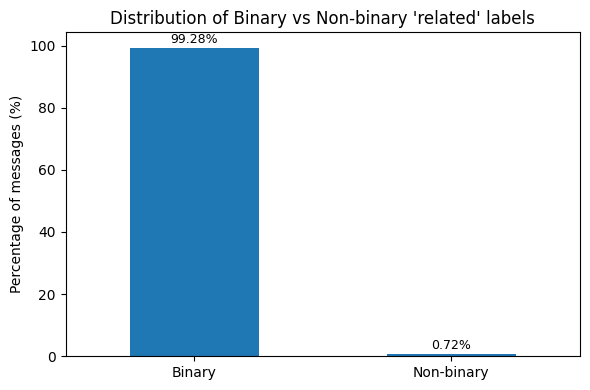

In [52]:
import matplotlib.pyplot as plt

total_ids = categories["id"].nunique()
non_binary_ids = len(ids_related_2)
binary_ids = total_ids - non_binary_ids
counts = pd.Series({"Binary": binary_ids,"Non-binary": non_binary_ids})
counts_pct = counts / counts.sum() * 100

plt.figure(figsize=(6, 4))
ax = counts_pct.plot(kind="bar")
plt.title("Distribution of Binary vs Non-binary 'related' labels")
plt.ylabel("Percentage of messages (%)")
plt.xticks(rotation=0)
for i, v in enumerate(counts_pct):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Drop non-binary samples

In [53]:
ids_to_drop = rel2["id"].unique()
categories_clean = categories[~categories["id"].isin(ids_to_drop)].copy()
categories_clean["related"].value_counts()

related
1    19929
0     6125
Name: count, dtype: int64

## Label aggregation

In [54]:
categories_agg = categories_clean.groupby("id", as_index=False).max()
categories_agg.to_csv("../data/raw/removed_duplicates/disaster_categories.csv")
print("Duplicate ids after aggregation:",categories_agg["id"].duplicated().sum())

Duplicate ids after aggregation: 0


## Inspect file

In [55]:
print(categories_agg.shape)
print(categories_agg.info())

(25992, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25992 entries, 0 to 25991
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      25992 non-null  int64
 1   related                 25992 non-null  int64
 2   request                 25992 non-null  int64
 3   offer                   25992 non-null  int64
 4   aid_related             25992 non-null  int64
 5   medical_help            25992 non-null  int64
 6   medical_products        25992 non-null  int64
 7   search_and_rescue       25992 non-null  int64
 8   security                25992 non-null  int64
 9   military                25992 non-null  int64
 10  child_alone             25992 non-null  int64
 11  water                   25992 non-null  int64
 12  food                    25992 non-null  int64
 13  shelter                 25992 non-null  int64
 14  clothing                25992 non-null  int64
 15  money  

In [56]:
categories_agg.head()

,id,related,request,offer,aid_related,medical_help,medical_products,search_and_rescue,security,military,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,1,0,0,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,8,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,1,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Check messages with vs without labels distribution

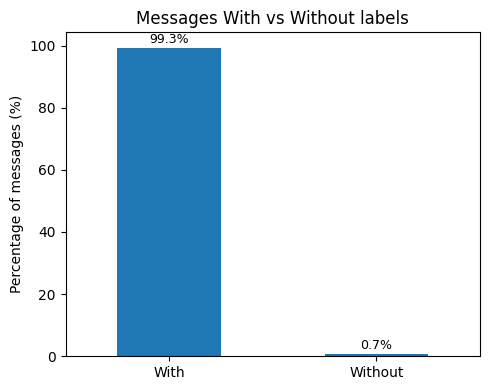

In [57]:
msg = pd.read_csv("../data/raw/removed_duplicates/disaster_messages.csv")
cat = pd.read_csv("../data/raw/removed_duplicates/disaster_categories.csv")
n_total = msg["id"].nunique()
ids_with_cat = set(cat["id"])
n_with = msg["id"].isin(ids_with_cat).sum()
n_without = n_total - n_with
counts = pd.Series({"With": n_with,"Without": n_without})
counts_pct = counts / counts.sum() * 100

plt.figure(figsize=(5, 4))
ax = counts_pct.plot(kind="bar")
plt.title("Messages With vs Without labels")
plt.ylabel("Percentage of messages (%)")
plt.xticks(rotation=0)

for i, v in enumerate(counts_pct):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Merge disaster dataset

In [58]:
disaster_df = msg.merge(cat, on="id", how="inner")
print(disaster_df.shape)
print(disaster_df.info())

(25992, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25992 entries, 0 to 25991
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Unnamed: 0_x            25992 non-null  int64 
 1   id                      25992 non-null  int64 
 2   message                 25992 non-null  object
 3   original                10021 non-null  object
 4   genre                   25992 non-null  object
 5   Unnamed: 0_y            25992 non-null  int64 
 6   related                 25992 non-null  int64 
 7   request                 25992 non-null  int64 
 8   offer                   25992 non-null  int64 
 9   aid_related             25992 non-null  int64 
 10  medical_help            25992 non-null  int64 
 11  medical_products        25992 non-null  int64 
 12  search_and_rescue       25992 non-null  int64 
 13  security                25992 non-null  int64 
 14  military                25992 non-null  in

In [59]:
disaster_df.head()

,Unnamed: 0_x,id,message,original,genre,Unnamed: 0_y,related,request,offer,aid_related,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,0,2,Weather update - a cold front from Cuba that c...,Un front froid se retrouve sur Cuba ce matin. ...,direct,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct,1,1,0,0,1,...,0,0,1,0,1,0,0,0,0,0
2,2,8,Looking for someone but no name,"Patnm, di Maryani relem pou li banm nouvel li ...",direct,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,9,UN reports Leogane 80-90 destroyed. Only Hospi...,UN reports Leogane 80-90 destroyed. Only Hospi...,direct,3,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,4,12,"says: west side of Haiti, rest of the country ...",facade ouest d Haiti et le reste du pays aujou...,direct,4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
